## Name - **Kavvya Mankulwar**  
## PRN - **202301100062**       
## BATCH - AIML4
## LAB ASSIGNMENT 1


Dataset: Real Estate Valuation Dataset  
Task: Predict House Price of Unit Area using a Neural Network




1: Import Libraries

In [37]:
# Only numpy, pandas, matplotlib — no deep learning frameworks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"Matplotlib ver : {matplotlib.__version__}")

Libraries imported successfully!
NumPy version  : 2.0.2
Pandas version : 2.2.2
Matplotlib ver : 3.10.0


2: Load Dataset

In [38]:
df = pd.read_excel('/content/drive/MyDrive/Real estate valuation data set.xlsx')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   No  X1 transaction date  X2 house age  \
0   1          2012.916667          32.0   
1   2          2012.916667          19.5   
2   3          2013.583333          13.3   
3   4          2013.500000          13.3   
4   5          2012.833333           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3

In [39]:
# Shape of the dataset
print("Shape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Shape of dataset: (414, 8)

Column Names:
['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']


In [40]:
# Data types of each column
print("Data Types:")
print(df.dtypes)

Data Types:
No                                          int64
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object


3: Data Understanding & Exploration

In [41]:
# Summary statistics
print("Basic Statistics:")
print(df.describe())

Basic Statistics:
               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
mean   207.500000          2013.148953     17.712560   
std    119.655756             0.281995     11.392485   
min      1.000000          2012.666667      0.000000   
25%    104.250000          2012.916667      9.025000   
50%    207.500000          2013.166667     16.100000   
75%    310.750000          2013.416667     28.150000   
max    414.000000          2013.583333     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience sto

In [42]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Total missing values: 0


In [43]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


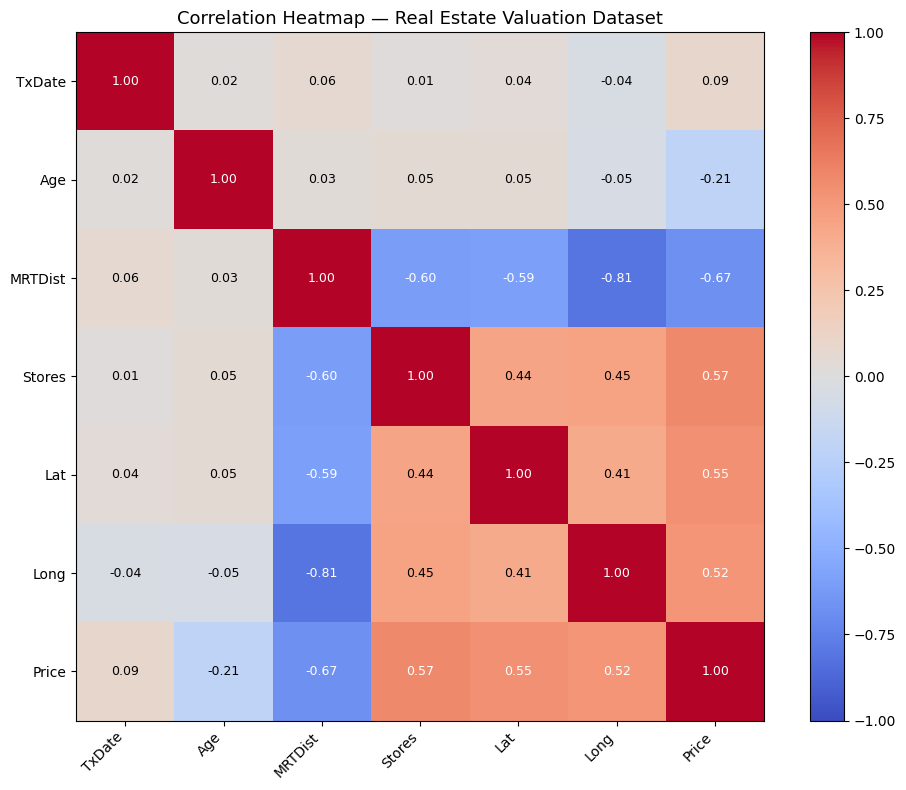

In [44]:
# Correlation Matrix — Heatmap

df_corr = df.drop(columns=['No'])
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Plot heatmap manually using imshow
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Set tick labels
short_labels = ['TxDate', 'Age', 'MRTDist', 'Stores', 'Lat', 'Long', 'Price']
ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_yticklabels(short_labels)

# Annotate cells with correlation values
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha='center', va='center', fontsize=9,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')

ax.set_title("Correlation Heatmap — Real Estate Valuation Dataset", fontsize=13)
plt.tight_layout()
plt.show()

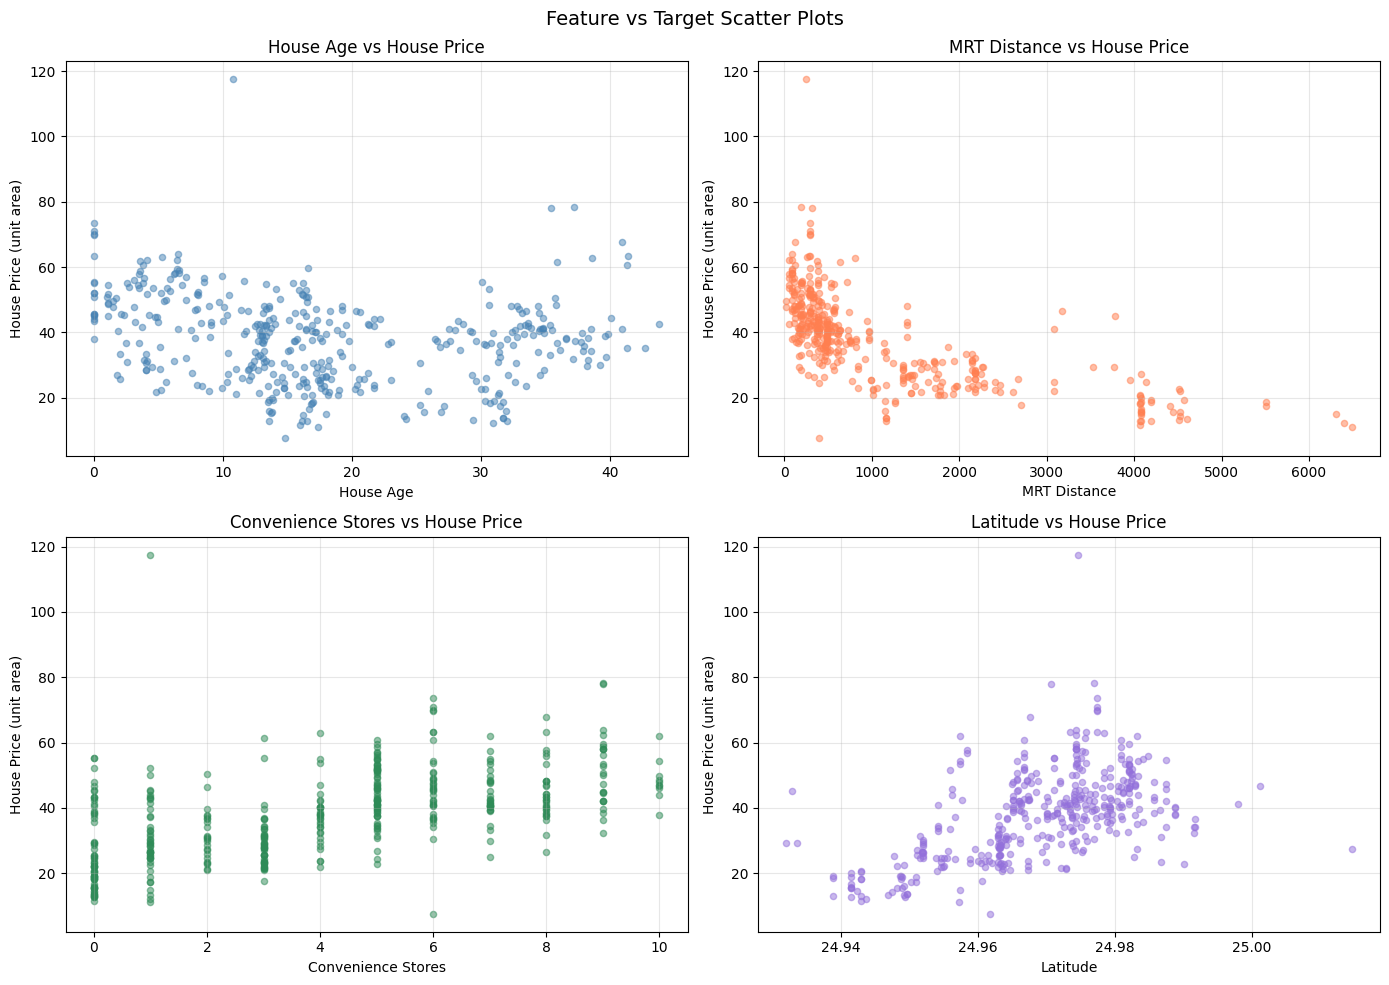

In [45]:
# Scatter Plots — Feature vs Target (House Price)

feature_cols = [
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
    'X5 latitude'
]
target_col = 'Y house price of unit area'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

short_names = ['House Age', 'MRT Distance', 'Convenience Stores', 'Latitude']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i, (col, name, color) in enumerate(zip(feature_cols, short_names, colors)):
    axes[i].scatter(df[col], df[target_col], alpha=0.5, color=color, s=20)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('House Price (unit area)')
    axes[i].set_title(f'{name} vs House Price')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature vs Target Scatter Plots', fontsize=14)
plt.tight_layout()
plt.show()

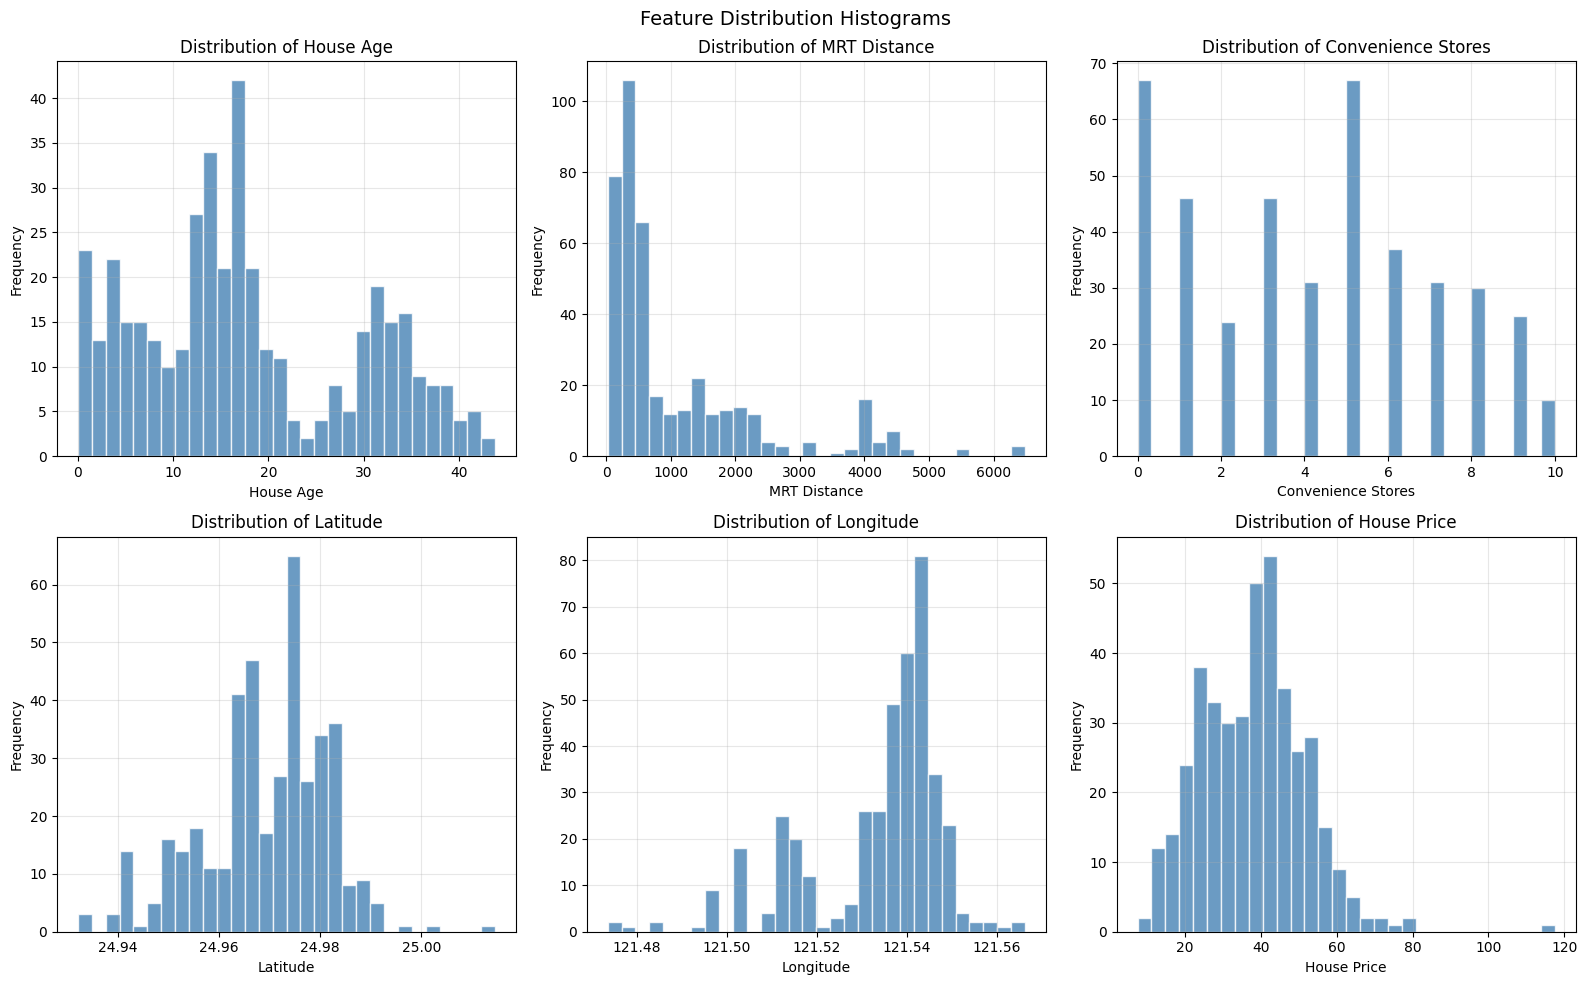

In [46]:
# Histograms — Distribution of Each Feature

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_features = [
    ('X2 house age', 'House Age'),
    ('X3 distance to the nearest MRT station', 'MRT Distance'),
    ('X4 number of convenience stores', 'Convenience Stores'),
    ('X5 latitude', 'Latitude'),
    ('X6 longitude', 'Longitude'),
    ('Y house price of unit area', 'House Price')
]

for i, (col, name) in enumerate(all_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {name}')
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution Histograms', fontsize=14)
plt.tight_layout()
plt.show()

4: Data Preprocessing

In [47]:
# Rename columns, select features & target, normalize, split

# Rename columns to cleaner descriptive names
df.columns = [
    'No',
    'Transaction_Date',
    'House_Age',
    'MRT_Distance',
    'Convenience_Stores',
    'Latitude',
    'Longitude',
    'House_Price'
]

print("Renamed columns:", df.columns.tolist())
print(df.head())

Renamed columns: ['No', 'Transaction_Date', 'House_Age', 'MRT_Distance', 'Convenience_Stores', 'Latitude', 'Longitude', 'House_Price']
   No  Transaction_Date  House_Age  MRT_Distance  Convenience_Stores  \
0   1       2012.916667       32.0      84.87882                  10   
1   2       2012.916667       19.5     306.59470                   9   
2   3       2013.583333       13.3     561.98450                   5   
3   4       2013.500000       13.3     561.98450                   5   
4   5       2012.833333        5.0     390.56840                   5   

   Latitude  Longitude  House_Price  
0  24.98298  121.54024         37.9  
1  24.98034  121.53951         42.2  
2  24.98746  121.54391         47.3  
3  24.98746  121.54391         54.8  
4  24.97937  121.54245         43.1  


In [48]:
# Select input features (X) and target (y)
# We drop the serial number 'No' column
# Features: Transaction_Date, House_Age, MRT_Distance,
#           Convenience_Stores, Latitude, Longitude
# Target  : House_Price

X = df.drop(columns=['No', 'House_Price']).values  # shape: (414, 6)
y = df['House_Price'].values                        # shape: (414,)

print("Shape of X (features):", X.shape)
print("Shape of y (target)  :", y.shape)

Shape of X (features): (414, 6)
Shape of y (target)  : (414,)


In [49]:
# Train-Test Split: 80% train, 20% test (manual, no sklearn)
np.random.seed(42)

indices = np.arange(X.shape[0])
np.random.shuffle(indices)

split_idx = int(0.8 * X.shape[0])
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx].reshape(-1, 1)  # column vector
y_test  = y[test_idx].reshape(-1, 1)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

X_train shape: (331, 6)
X_test  shape: (83, 6)
y_train shape: (331, 1)
y_test  shape: (83, 1)


In [50]:
# Standardization (Z-score normalization)
# Formula: X_scaled = (X - mean) / std

X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std

print("Mean of scaled train features (should be ~0):")
print(X_train_scaled.mean(axis=0).round(4))

print("\nStd of scaled train features (should be ~1):")
print(X_train_scaled.std(axis=0).round(4))

Mean of scaled train features (should be ~0):
[ 0.  0.  0. -0.  0. -0.]

Std of scaled train features (should be ~1):
[1. 1. 1. 1. 1. 1.]


5: Neural Network Architecture

```
Architecture:
  Input Layer  : 6 neurons  (one per feature)
  Hidden Layer : 5 neurons  (configurable)
  Output Layer : 1 neuron   (house price — regression)

Activation:
  Hidden layer → Sigmoid
  Output layer → Linear (no activation)
```

6: Weight Initialization

In [51]:
# Small random values to break symmetry

input_size  = X_train_scaled.shape[1]  # 6 features
hidden_size = 5                         # configurable
output_size = 1                         # regression: 1 output

def init_weights(input_size, hidden_size, output_size, seed=42):
    """
    Initialize weights with small random values.
    W1 : shape (input_size  x hidden_size)  — connections: input  → hidden
    b1 : shape (1           x hidden_size)  — bias for hidden layer
    W2 : shape (hidden_size x output_size)  — connections: hidden → output
    b2 : shape (1           x output_size)  — bias for output layer
    """
    np.random.seed(seed)
    W1 = np.random.randn(input_size,  hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_weights(input_size, hidden_size, output_size)

print("Weight and Bias Shapes:")
print(f"  W1 : {W1.shape}  (input_size={input_size}  → hidden_size={hidden_size})")
print(f"  b1 : {b1.shape}")
print(f"  W2 : {W2.shape}  (hidden_size={hidden_size} → output_size={output_size})")
print(f"  b2 : {b2.shape}")

print("\nInitial W1 (first row):", W1[0])
print("Initial W2 (first col):", W2[:, 0])

Weight and Bias Shapes:
  W1 : (6, 5)  (input_size=6  → hidden_size=5)
  b1 : (1, 5)
  W2 : (5, 1)  (hidden_size=5 → output_size=1)
  b2 : (1, 1)

Initial W1 (first row): [ 0.04967142 -0.01382643  0.06476885  0.15230299 -0.02341534]
Initial W2 (first col): [-0.06017066  0.18522782 -0.00134972 -0.10577109  0.08225449]


7: Activation Function

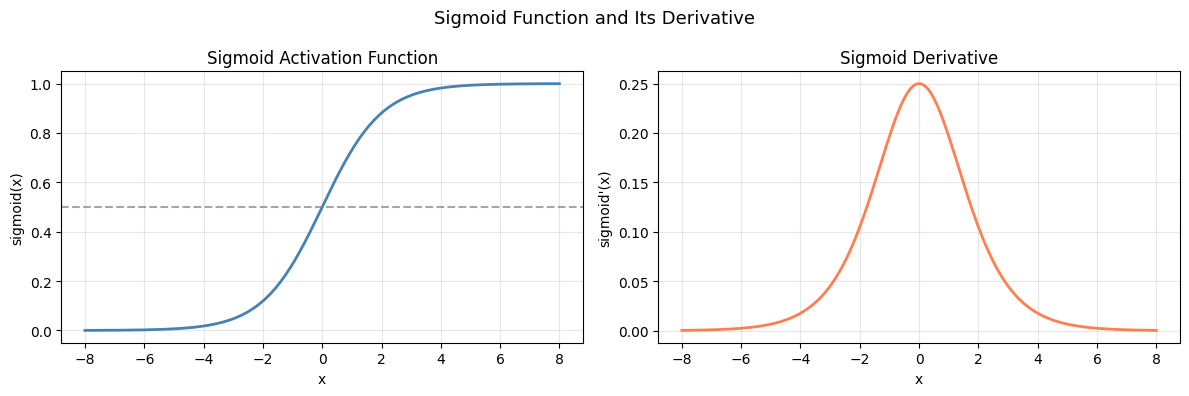

sigmoid(0)  = 0.5
sigmoid(10) = 0.999955
sigmoid(-10)= 4.5e-05


In [52]:
# Sigmoid squashes inputs to range (0, 1)
# Formula: sigmoid(x) = 1 / (1 + e^(-x))
# Derivative: sigmoid'(x) = sigmoid(x) * (1 - sigmoid(x))

def sigmoid(x):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(A):
    """
    Derivative of sigmoid given its OUTPUT A = sigmoid(x).
    sigmoid'(x) = A * (1 - A)
    """
    return A * (1.0 - A)

# Visualize the sigmoid function
x_vals = np.linspace(-8, 8, 200)
y_vals = sigmoid(x_vals)
dy_vals = sigmoid_derivative(y_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_vals, y_vals, color='steelblue', linewidth=2)
axes[0].set_title('Sigmoid Activation Function')
axes[0].set_xlabel('x')
axes[0].set_ylabel('sigmoid(x)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, dy_vals, color='coral', linewidth=2)
axes[1].set_title('Sigmoid Derivative')
axes[1].set_xlabel('x')
axes[1].set_ylabel("sigmoid'(x)")
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sigmoid Function and Its Derivative', fontsize=13)
plt.tight_layout()
plt.show()

print("sigmoid(0)  =", sigmoid(0))
print("sigmoid(10) =", round(sigmoid(10), 6))
print("sigmoid(-10)=", round(sigmoid(-10), 6))

8: Forward Propagation

In [53]:

# Hidden layer:
#   Z1 = X · W1 + b1          (linear combination)
#   A1 = sigmoid(Z1)           (apply activation)
# Output layer:
#   Z2 = A1 · W2 + b2          (linear combination)
#   y_pred = Z2                 (linear output for regression)


def forward_propagation(X, W1, b1, W2, b2):
    """
    Perform forward propagation through the network.

    Parameters:
        X  : input data,   shape (m, input_size)
        W1 : weights layer 1, shape (input_size, hidden_size)
        b1 : bias layer 1,    shape (1, hidden_size)
        W2 : weights layer 2, shape (hidden_size, output_size)
        b2 : bias layer 2,    shape (1, output_size)

    Returns:
        Z1, A1, Z2, y_pred
    """
    # Hidden layer: linear combination + sigmoid
    Z1 = np.dot(X, W1) + b1       # shape: (m, hidden_size)
    A1 = sigmoid(Z1)               # shape: (m, hidden_size)

    # Output layer: linear (no activation for regression)
    Z2     = np.dot(A1, W2) + b2   # shape: (m, output_size)
    y_pred = Z2                     # shape: (m, 1)

    return Z1, A1, Z2, y_pred

# Test forward pass on training data
Z1, A1, Z2, y_pred = forward_propagation(X_train_scaled, W1, b1, W2, b2)

print("Forward Propagation — Shape Check:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  Z1             : {Z1.shape}")
print(f"  A1             : {A1.shape}")
print(f"  Z2 (y_pred)    : {Z2.shape}")
print(f"\nFirst 5 predictions: {y_pred[:5].flatten().round(2)}")
print(f"First 5 actuals    : {y_train[:5].flatten().round(2)}")

Forward Propagation — Shape Check:
  X_train_scaled : (331, 6)
  Z1             : (331, 5)
  A1             : (331, 5)
  Z2 (y_pred)    : (331, 1)

First 5 predictions: [0.03 0.05 0.04 0.06 0.07]
First 5 actuals    : [45.1 42.3 52.2 37.3 22.8]


9: Loss Function (MSE)

In [54]:
# MSE = (1/m) * Σ (y_true - y_pred)²
# where m = number of training samples

def compute_mse(y_true, y_pred):
    """
    Compute Mean Squared Error.
    y_true and y_pred: shape (m, 1)
    """
    return np.mean((y_true - y_pred) ** 2)

initial_loss = compute_mse(y_train, y_pred)
print(f"Initial MSE Loss (before training): {initial_loss:.4f}")

Initial MSE Loss (before training): 1580.1006


10: Backpropagation

In [55]:

# Compute gradients of loss with respect to all parameters.

# Output layer gradients:
#   dL/dZ2 = (y_pred - y_true) / m       → dZ2
#   dL/dW2 = A1.T · dZ2                  → dW2
#   dL/db2 = sum(dZ2, axis=0)            → db2

# Hidden layer gradients:
#   dL/dA1 = dZ2 · W2.T                  → dA1
#   dL/dZ1 = dA1 * sigmoid_deriv(A1)     → dZ1
#   dL/dW1 = X.T · dZ1                   → dW1
#   dL/db1 = sum(dZ1, axis=0)            → db1

def backpropagation(X, y_true, y_pred, A1, W2):
    """
    Compute gradients via backpropagation.

    Returns: dW1, db1, dW2, db2
    """
    m = y_true.shape[0]  # number of samples

    # --- Output Layer Gradient ---
    # Derivative of MSE w.r.t. output Z2
    dZ2 = (y_pred - y_true) / m    # shape: (m, 1)
    dW2 = np.dot(A1.T, dZ2)        # shape: (hidden_size, 1)
    db2 = np.sum(dZ2, axis=0, keepdims=True)  # shape: (1, 1)

    # --- Hidden Layer Gradient ---
    dA1 = np.dot(dZ2, W2.T)                  # shape: (m, hidden_size)
    dZ1 = dA1 * sigmoid_derivative(A1)        # shape: (m, hidden_size)
    dW1 = np.dot(X.T, dZ1)                    # shape: (input_size, hidden_size)
    db1 = np.sum(dZ1, axis=0, keepdims=True)  # shape: (1, hidden_size)

    return dW1, db1, dW2, db2

# Test backprop on current predictions
dW1, db1_g, dW2, db2_g = backpropagation(X_train_scaled, y_train, y_pred, A1, W2)

print("Backpropagation — Gradient Shape Check:")
print(f"  dZ2 (computed inside function)")
print(f"  dW2 : {dW2.shape}")
print(f"  db2 : {db2_g.shape}")
print(f"  dW1 : {dW1.shape}")
print(f"  db1 : {db1_g.shape}")

Backpropagation — Gradient Shape Check:
  dZ2 (computed inside function)
  dW2 : (5, 1)
  db2 : (1, 1)
  dW1 : (6, 5)
  db1 : (1, 5)


11: Gradient Descent (Weight Update)

In [56]:
# W = W - learning_rate * dW
# b = b - learning_rate * db

def update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    """
    Update weights using gradient descent.
    lr = learning rate (step size)
    """
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    return W1, b1, W2, b2

print("Weight update function defined.")
print("Formula: W_new = W_old - learning_rate * gradient")

Weight update function defined.
Formula: W_new = W_old - learning_rate * gradient


12: Training (Batch Gradient Descent — Baseline)

In [57]:
# Batch Gradient Descent (uses all training data per update)

def train_batch_gd(X, y, input_size, hidden_size, output_size,
                   lr=0.01, epochs=1000, print_every=100, seed=42):
    """
    Train neural network using Batch Gradient Descent.
    Returns: trained weights, loss history
    """
    W1, b1, W2, b2 = init_weights(input_size, hidden_size, output_size, seed)
    loss_history = []

    for epoch in range(epochs):
        # Forward pass
        Z1, A1, Z2, y_pred = forward_propagation(X, W1, b1, W2, b2)

        # Compute loss
        loss = compute_mse(y, y_pred)
        loss_history.append(loss)

        # Backpropagation
        dW1, db1, dW2, db2 = backpropagation(X, y, y_pred, A1, W2)

        # Update weights
        W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

        if epoch % print_every == 0:
            print(f"  Epoch {epoch:5d} | Loss: {loss:.4f}")

    return W1, b1, W2, b2, loss_history

print("Training with Batch GD (lr=0.01, 1000 epochs)...")
W1_trained, b1_trained, W2_trained, b2_trained, loss_hist = train_batch_gd(
    X_train_scaled, y_train,
    input_size, hidden_size, output_size,
    lr=0.01, epochs=1000, print_every=100
)
print(f"\nFinal Training Loss: {loss_hist[-1]:.4f}")

Training with Batch GD (lr=0.01, 1000 epochs)...
  Epoch     0 | Loss: 1580.1006
  Epoch   100 | Loss: 74.4426
  Epoch   200 | Loss: 64.3187
  Epoch   300 | Loss: 60.7572
  Epoch   400 | Loss: 58.5912
  Epoch   500 | Loss: 57.1047
  Epoch   600 | Loss: 55.7055
  Epoch   700 | Loss: 54.0765
  Epoch   800 | Loss: 52.4210
  Epoch   900 | Loss: 50.9265

Final Training Loss: 49.6358


13: Loss vs Epoch Visualization

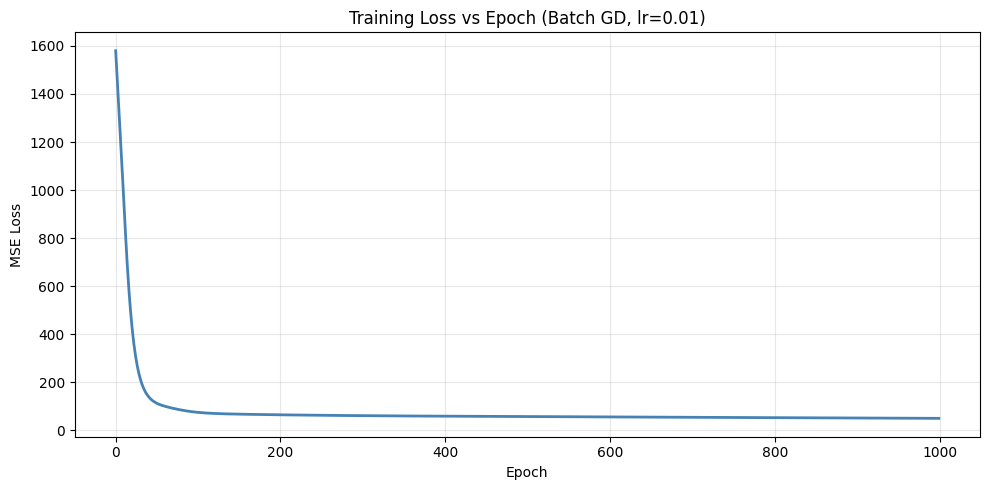

Starting Loss : 1580.1006
Final Loss    : 49.6358
Improvement   : 1530.4648


In [58]:
plt.figure(figsize=(10, 5))
plt.plot(loss_hist, color='steelblue', linewidth=2)
plt.title('Training Loss vs Epoch (Batch GD, lr=0.01)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting Loss : {loss_hist[0]:.4f}")
print(f"Final Loss    : {loss_hist[-1]:.4f}")
print(f"Improvement   : {loss_hist[0] - loss_hist[-1]:.4f}")

14: Experiments

Learning Rate Experiment:

Training with lr=0.001...
  Epoch     0 | Loss: 1580.1006
  Epoch   500 | Loss: 113.4486
  Final Loss: 74.7821

Training with lr=0.01...
  Epoch     0 | Loss: 1580.1006
  Epoch   500 | Loss: 57.1047
  Final Loss: 49.6358

Training with lr=0.1...
  Epoch     0 | Loss: 1580.1006
  Epoch   500 | Loss: 38.7809
  Final Loss: 37.4881


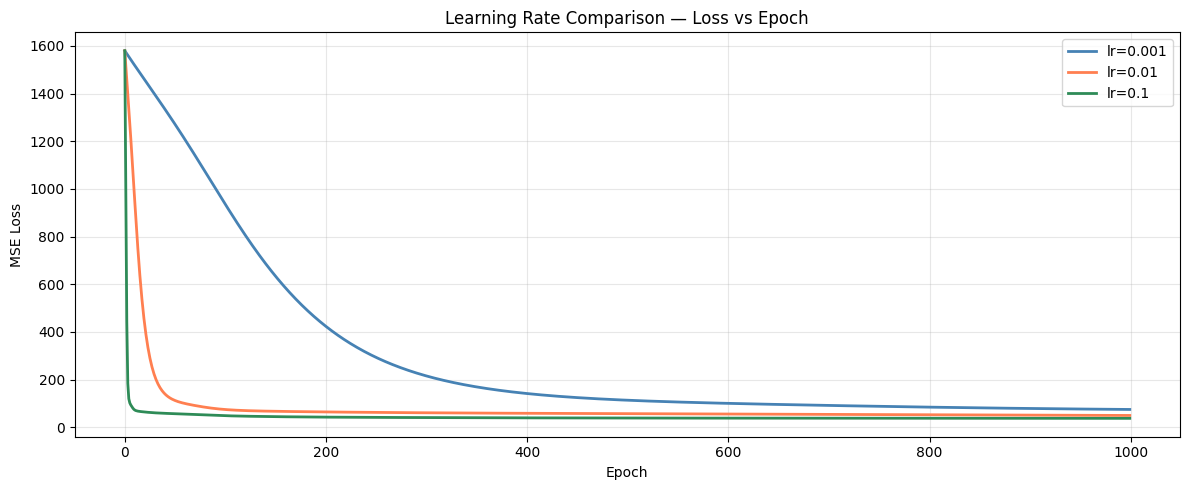


Summary:
  lr=0.001  → Final Loss: 74.7821
  lr=0.01   → Final Loss: 49.6358
  lr=0.1    → Final Loss: 37.4881


In [59]:
# Try lr = 0.001, 0.01, 0.1 and compare convergence

learning_rates = [0.001, 0.01, 0.1]
lr_losses = {}

print("Learning Rate Experiment:")
print("="*50)

for lr in learning_rates:
    print(f"\nTraining with lr={lr}...")
    _, _, _, _, lh = train_batch_gd(
        X_train_scaled, y_train,
        input_size, hidden_size, output_size,
        lr=lr, epochs=1000, print_every=500
    )
    lr_losses[lr] = lh
    print(f"  Final Loss: {lh[-1]:.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))
colors = ['steelblue', 'coral', 'seagreen']
for (lr, lh), c in zip(lr_losses.items(), colors):
    plt.plot(lh, label=f'lr={lr}', color=c, linewidth=2)

plt.title('Learning Rate Comparison — Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
for lr, lh in lr_losses.items():
    print(f"  lr={lr:<6} → Final Loss: {lh[-1]:.4f}")

Hidden Layer Size Experiment:

Training with hidden_size=1...
  Epoch     0 | Loss: 1577.7002
  Epoch   500 | Loss: 65.8502
  Final Loss: 60.0509

Training with hidden_size=3...
  Epoch     0 | Loss: 1586.6435
  Epoch   500 | Loss: 57.3421
  Final Loss: 49.7977

Training with hidden_size=5...
  Epoch     0 | Loss: 1580.1006
  Epoch   500 | Loss: 57.1047
  Final Loss: 49.6358

Training with hidden_size=10...
  Epoch     0 | Loss: 1584.3447
  Epoch   500 | Loss: 55.4725
  Final Loss: 51.0135


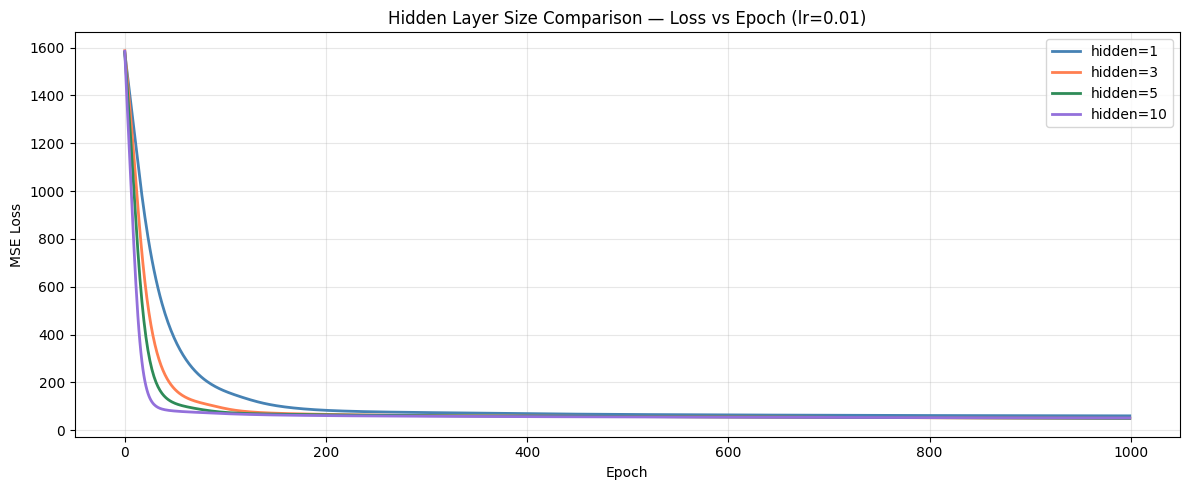


Summary:
  hidden_size=1   → Final Loss: 60.0509
  hidden_size=3   → Final Loss: 49.7977
  hidden_size=5   → Final Loss: 49.6358
  hidden_size=10  → Final Loss: 51.0135


In [60]:
# Try hidden_size = 1, 3, 5, 10 and compare loss

hidden_sizes = [1, 3, 5, 10]
hs_losses = {}

print("Hidden Layer Size Experiment:")
print("="*50)

for hs in hidden_sizes:
    print(f"\nTraining with hidden_size={hs}...")
    _, _, _, _, lh = train_batch_gd(
        X_train_scaled, y_train,
        input_size, hs, output_size,
        lr=0.01, epochs=1000, print_every=500
    )
    hs_losses[hs] = lh
    print(f"  Final Loss: {lh[-1]:.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))
palette = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
for (hs, lh), c in zip(hs_losses.items(), palette):
    plt.plot(lh, label=f'hidden={hs}', color=c, linewidth=2)

plt.title('Hidden Layer Size Comparison — Loss vs Epoch (lr=0.01)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
for hs, lh in hs_losses.items():
    print(f"  hidden_size={hs:<3} → Final Loss: {lh[-1]:.4f}")

15: Optimization Techniques

Training Batch GD...
Training SGD...
Training Mini-Batch GD...


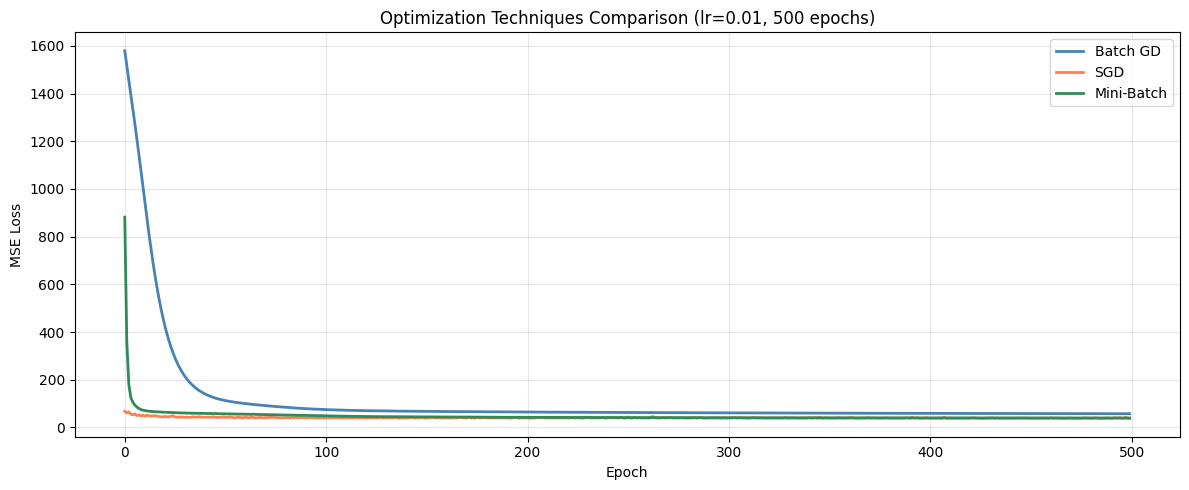


Final Losses:
  Batch GD   : 57.1182
  SGD        : 37.8550
  Mini-Batch : 39.1265


In [61]:

# 1. Batch Gradient Descent    — uses ALL data per update
# 2. Stochastic GD (SGD)       — uses ONE sample per update
# 3. Mini-Batch GD             — uses a BATCH per update

# ---- 15A: Batch Gradient Descent ----
def train_batch(X, y, hidden_size=5, lr=0.01, epochs=1000, seed=42):
    """Standard Batch Gradient Descent."""
    n_in = X.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, 1, seed)
    loss_hist = []

    for epoch in range(epochs):
        _, A1, _, y_pred = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_mse(y, y_pred))
        dW1, db1, dW2, db2 = backpropagation(X, y, y_pred, A1, W2)
        W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

    return W1, b1, W2, b2, loss_hist


# ---- 15B: Stochastic Gradient Descent (SGD) ----
def train_sgd(X, y, hidden_size=5, lr=0.01, epochs=1000, seed=42):
    """
    Stochastic Gradient Descent:
    Update weights after EACH individual training sample.
    Very noisy but can escape local minima.
    """
    n_in = X.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, 1, seed)
    loss_hist = []
    m = X.shape[0]

    for epoch in range(epochs):
        idx = np.random.permutation(m)  # shuffle each epoch
        for i in idx:
            Xi = X[i:i+1]   # shape (1, n_in)
            yi = y[i:i+1]   # shape (1, 1)
            _, A1, _, y_pred = forward_propagation(Xi, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backpropagation(Xi, yi, y_pred, A1, W2)
            W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)


        _, _, _, y_full = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_mse(y, y_full))

    return W1, b1, W2, b2, loss_hist


# ---- 15C: Mini-Batch Gradient Descent ----
def train_minibatch(X, y, hidden_size=5, lr=0.01, epochs=1000,
                    batch_size=32, seed=42):
    """
    Mini-Batch Gradient Descent:
    Update weights after processing a small batch.
    Balance between Batch GD (stable) and SGD (fast).
    """
    n_in = X.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, 1, seed)
    loss_hist = []
    m = X.shape[0]

    for epoch in range(epochs):
        idx = np.random.permutation(m)
        X_shuf = X[idx]
        y_shuf = y[idx]

        for start in range(0, m, batch_size):
            Xb = X_shuf[start:start+batch_size]
            yb = y_shuf[start:start+batch_size]
            _, A1, _, y_pred = forward_propagation(Xb, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backpropagation(Xb, yb, y_pred, A1, W2)
            W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

        _, _, _, y_full = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_mse(y, y_full))

    return W1, b1, W2, b2, loss_hist


EPOCHS = 500
LR     = 0.01

print("Training Batch GD...")
_, _, _, _, loss_batch = train_batch(X_train_scaled, y_train,
                                      hidden_size=5, lr=LR, epochs=EPOCHS)

print("Training SGD...")
_, _, _, _, loss_sgd = train_sgd(X_train_scaled, y_train,
                                  hidden_size=5, lr=LR, epochs=EPOCHS)

print("Training Mini-Batch GD...")
_, _, _, _, loss_mb = train_minibatch(X_train_scaled, y_train,
                                       hidden_size=5, lr=LR, epochs=EPOCHS, batch_size=32)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(loss_batch, label='Batch GD',    color='steelblue', linewidth=2)
plt.plot(loss_sgd,   label='SGD',         color='coral',     linewidth=2)
plt.plot(loss_mb,    label='Mini-Batch',  color='seagreen',  linewidth=2)
plt.title('Optimization Techniques Comparison (lr=0.01, 500 epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal Losses:")
print(f"  Batch GD   : {loss_batch[-1]:.4f}")
print(f"  SGD        : {loss_sgd[-1]:.4f}")
print(f"  Mini-Batch : {loss_mb[-1]:.4f}")

16: Advanced Optimizers

Training with Momentum optimizer...


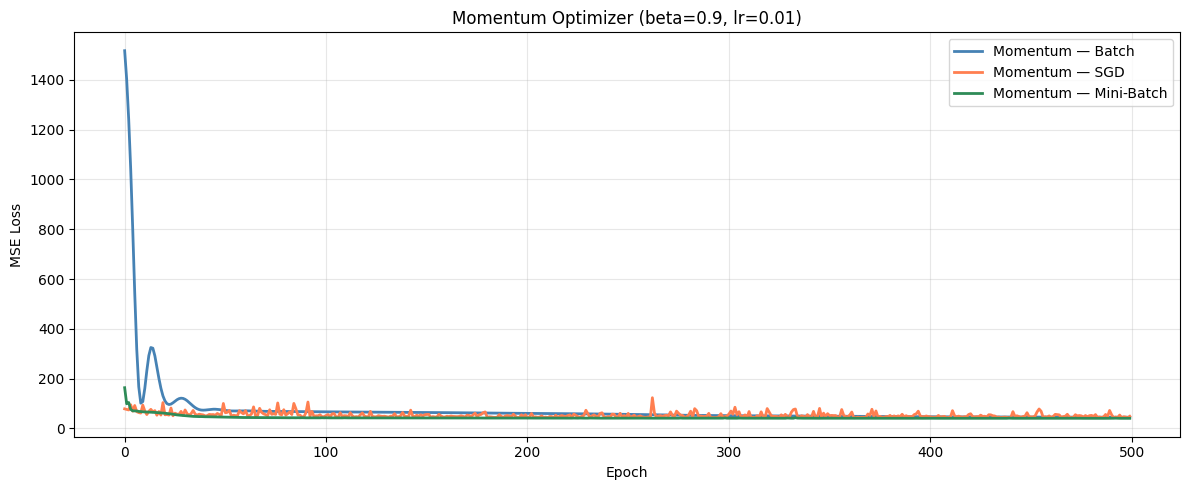

Momentum Final Losses:
  Batch     : 44.8336
  SGD       : 48.6800
  Mini-Batch: 40.4852


In [62]:
# Standard gradient descent can oscillate or converge slowly.
# Momentum accumulates a velocity vector in directions of
# persistent reduction in the objective function.

# Velocity update:
#   v = beta * v - lr * gradient
# Weight update:
#   W = W + v

def train_momentum(X, y, hidden_size=5, lr=0.01, epochs=500,
                   beta=0.9, batch_type='batch', batch_size=32, seed=42):
    """
    Train with Momentum optimizer.
    batch_type: 'batch' | 'sgd' | 'minibatch'
    """
    n_in = X.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, 1, seed)
    m = X.shape[0]
    loss_hist = []

    # Initialize velocities to zero
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    def momentum_update(W1, b1, W2, b2, dW1, db1, dW2, db2):
        nonlocal vW1, vb1, vW2, vb2
        # Update velocities
        vW1 = beta * vW1 - lr * dW1
        vb1 = beta * vb1 - lr * db1
        vW2 = beta * vW2 - lr * dW2
        vb2 = beta * vb2 - lr * db2
        # Apply velocity
        return W1 + vW1, b1 + vb1, W2 + vW2, b2 + vb2

    for epoch in range(epochs):
        if batch_type == 'batch':
            _, A1, _, y_pred = forward_propagation(X, W1, b1, W2, b2)
            dW1g, db1g, dW2g, db2g = backpropagation(X, y, y_pred, A1, W2)
            W1, b1, W2, b2 = momentum_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)

        elif batch_type == 'sgd':
            idx = np.random.permutation(m)
            for i in idx:
                Xi, yi = X[i:i+1], y[i:i+1]
                _, A1, _, y_pred = forward_propagation(Xi, W1, b1, W2, b2)
                dW1g, db1g, dW2g, db2g = backpropagation(Xi, yi, y_pred, A1, W2)
                W1, b1, W2, b2 = momentum_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)

        else:  # minibatch
            idx = np.random.permutation(m)
            for start in range(0, m, batch_size):
                Xb = X[idx[start:start+batch_size]]
                yb = y[idx[start:start+batch_size]]
                _, A1, _, y_pred = forward_propagation(Xb, W1, b1, W2, b2)
                dW1g, db1g, dW2g, db2g = backpropagation(Xb, yb, y_pred, A1, W2)
                W1, b1, W2, b2 = momentum_update(W1, b1, W2, b2, dW1g, db1g, dW2g, db2g)

        _, _, _, y_full = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_mse(y, y_full))

    return W1, b1, W2, b2, loss_hist


print("Training with Momentum optimizer...")
_, _, _, _, loss_mom_batch = train_momentum(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='batch')
_, _, _, _, loss_mom_sgd   = train_momentum(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='sgd')
_, _, _, _, loss_mom_mb    = train_momentum(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='minibatch')

plt.figure(figsize=(12, 5))
plt.plot(loss_mom_batch, label='Momentum — Batch',     color='steelblue', linewidth=2)
plt.plot(loss_mom_sgd,   label='Momentum — SGD',       color='coral',     linewidth=2)
plt.plot(loss_mom_mb,    label='Momentum — Mini-Batch',color='seagreen',  linewidth=2)
plt.title('Momentum Optimizer (beta=0.9, lr=0.01)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Momentum Final Losses:")
print(f"  Batch     : {loss_mom_batch[-1]:.4f}")
print(f"  SGD       : {loss_mom_sgd[-1]:.4f}")
print(f"  Mini-Batch: {loss_mom_mb[-1]:.4f}")

Training with Nesterov optimizer...


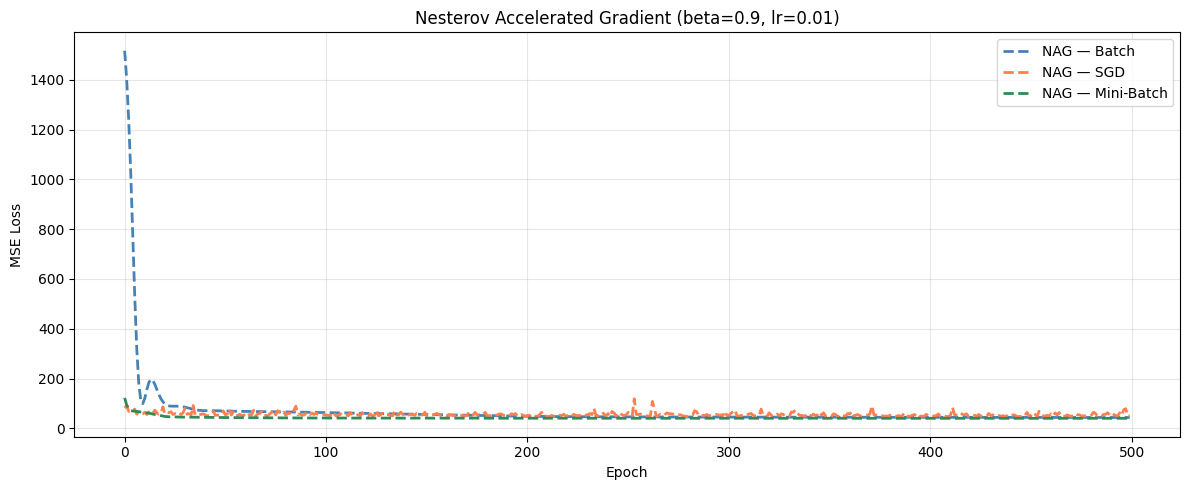

Nesterov Final Losses:
  Batch     : 43.3149
  SGD       : 50.5232
  Mini-Batch: 40.0120


In [63]:
# NESTEROV ACCELERATED GRADIENT (NAG)

# Look-ahead weights:
#   W_look = W + beta * v

# Compute gradient at look-ahead position:
#   gradient = backprop(W_look)
#
# Update velocity and weights:
#   v = beta * v - lr * gradient
#   W = W + v


def train_nesterov(X, y, hidden_size=5, lr=0.01, epochs=500,
                   beta=0.9, batch_type='batch', batch_size=32, seed=42):
    """
    Train with Nesterov Accelerated Gradient optimizer.
    batch_type: 'batch' | 'sgd' | 'minibatch'
    """
    n_in = X.shape[1]
    W1, b1, W2, b2 = init_weights(n_in, hidden_size, 1, seed)
    m = X.shape[0]
    loss_hist = []

    # Initialize velocities
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    def nag_step(Xi, yi, W1, b1, W2, b2):
        nonlocal vW1, vb1, vW2, vb2
        # Look-ahead (preview) position
        W1_la = W1 + beta * vW1
        b1_la = b1 + beta * vb1
        W2_la = W2 + beta * vW2
        b2_la = b2 + beta * vb2

        # Gradient at look-ahead
        _, A1_la, _, y_pred_la = forward_propagation(Xi, W1_la, b1_la, W2_la, b2_la)
        dW1g, db1g, dW2g, db2g = backpropagation(Xi, yi, y_pred_la, A1_la, W2_la)

        # Update velocities
        vW1 = beta * vW1 - lr * dW1g
        vb1 = beta * vb1 - lr * db1g
        vW2 = beta * vW2 - lr * dW2g
        vb2 = beta * vb2 - lr * db2g

        # Apply velocity
        return W1 + vW1, b1 + vb1, W2 + vW2, b2 + vb2

    for epoch in range(epochs):
        if batch_type == 'batch':
            W1, b1, W2, b2 = nag_step(X, y, W1, b1, W2, b2)

        elif batch_type == 'sgd':
            idx = np.random.permutation(m)
            for i in idx:
                W1, b1, W2, b2 = nag_step(X[i:i+1], y[i:i+1], W1, b1, W2, b2)

        else:  # minibatch
            idx = np.random.permutation(m)
            for start in range(0, m, batch_size):
                Xb = X[idx[start:start+batch_size]]
                yb = y[idx[start:start+batch_size]]
                W1, b1, W2, b2 = nag_step(Xb, yb, W1, b1, W2, b2)

        _, _, _, y_full = forward_propagation(X, W1, b1, W2, b2)
        loss_hist.append(compute_mse(y, y_full))

    return W1, b1, W2, b2, loss_hist


print("Training with Nesterov optimizer...")
_, _, _, _, loss_nag_batch = train_nesterov(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='batch')
_, _, _, _, loss_nag_sgd   = train_nesterov(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='sgd')
_, _, _, _, loss_nag_mb    = train_nesterov(
    X_train_scaled, y_train, lr=0.01, epochs=500, beta=0.9, batch_type='minibatch')

plt.figure(figsize=(12, 5))
plt.plot(loss_nag_batch, label='NAG — Batch',     color='steelblue', linestyle='--', linewidth=2)
plt.plot(loss_nag_sgd,   label='NAG — SGD',       color='coral',     linestyle='--', linewidth=2)
plt.plot(loss_nag_mb,    label='NAG — Mini-Batch',color='seagreen',  linestyle='--', linewidth=2)
plt.title('Nesterov Accelerated Gradient (beta=0.9, lr=0.01)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nesterov Final Losses:")
print(f"  Batch     : {loss_nag_batch[-1]:.4f}")
print(f"  SGD       : {loss_nag_sgd[-1]:.4f}")
print(f"  Mini-Batch: {loss_nag_mb[-1]:.4f}")

17: Full Optimizer Comparison

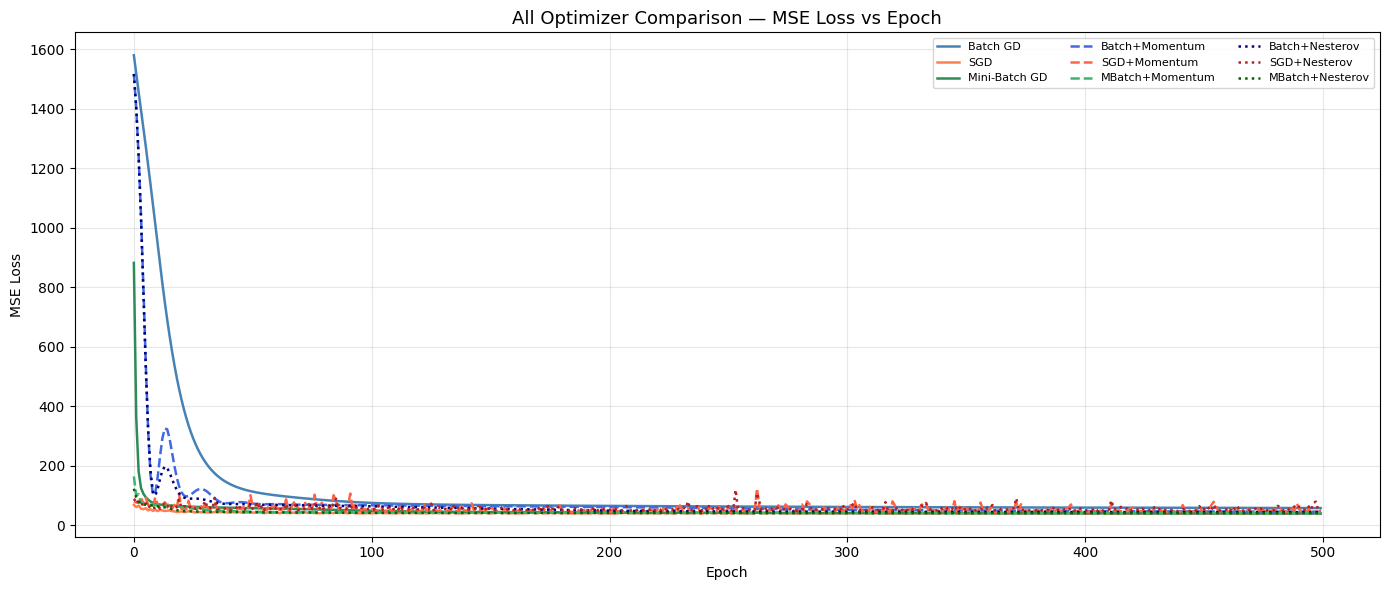

/tmp/ipykernel_2279/3507257166.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)


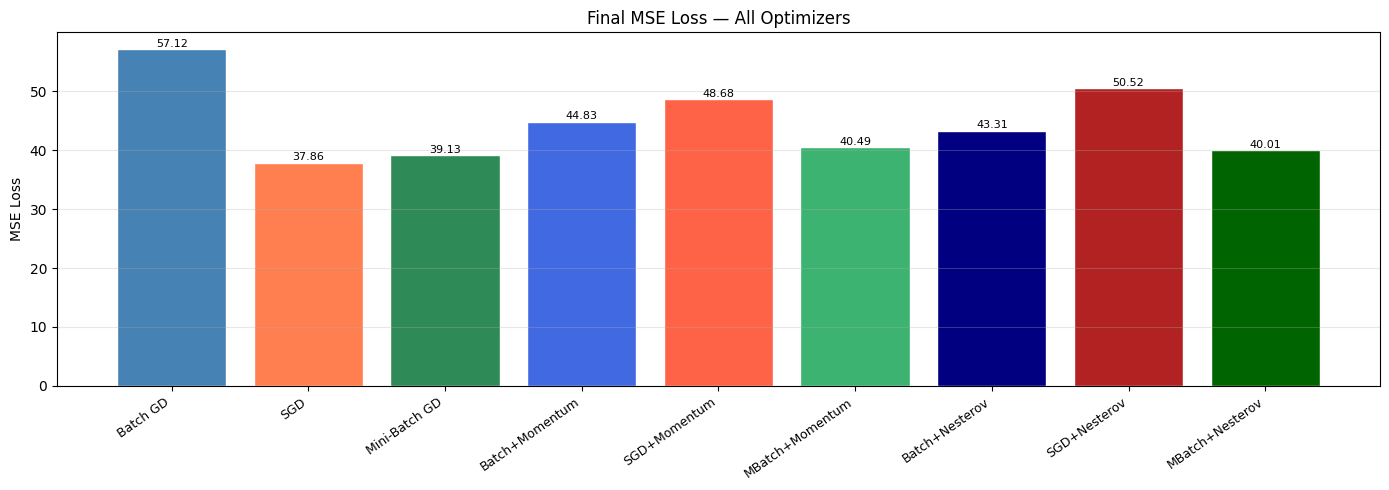

Optimizer                Final Loss
------------------------------------
  SGD                     37.8550
  Mini-Batch GD           39.1265
  MBatch+Nesterov         40.0120
  MBatch+Momentum         40.4852
  Batch+Nesterov          43.3149
  Batch+Momentum          44.8336
  SGD+Momentum            48.6800
  SGD+Nesterov            50.5232
  Batch GD                57.1182

 Best Optimizer : SGD  |  Final Loss: 37.8550


In [64]:
# Compare all 9 combinations across 3 optimizers × 3 methods

all_results = {
    'Batch GD'          : loss_batch,
    'SGD'               : loss_sgd,
    'Mini-Batch GD'     : loss_mb,
    'Batch+Momentum'    : loss_mom_batch,
    'SGD+Momentum'      : loss_mom_sgd,
    'MBatch+Momentum'   : loss_mom_mb,
    'Batch+Nesterov'    : loss_nag_batch,
    'SGD+Nesterov'      : loss_nag_sgd,
    'MBatch+Nesterov'   : loss_nag_mb,
}

# --- Line Plot — All Optimizers ---
fig, ax = plt.subplots(figsize=(14, 6))

palette = [
    'steelblue', 'coral', 'seagreen',
    'royalblue', 'tomato', 'mediumseagreen',
    'navy', 'firebrick', 'darkgreen'
]
styles = ['-', '-', '-', '--', '--', '--', ':', ':', ':']

for (name, lh), c, s in zip(all_results.items(), palette, styles):
    ax.plot(lh, label=name, color=c, linestyle=s, linewidth=1.8)

ax.set_title('All Optimizer Comparison — MSE Loss vs Epoch', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(ncol=3, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Bar Chart — Final Loss ---
names       = list(all_results.keys())
final_losses = [lh[-1] for lh in all_results.values()]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, final_losses, color=palette, edgecolor='white')
for bar, val in zip(bars, final_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Final MSE Loss — All Optimizers')
ax.set_ylabel('MSE Loss')
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Print Summary Table ---
print(f"{'Optimizer':<22} {'Final Loss':>12}")
print("-" * 36)
sorted_res = sorted(all_results.items(), key=lambda x: x[1][-1])
for name, lh in sorted_res:
    print(f"  {name:<20} {lh[-1]:>10.4f}")

best = sorted_res[0]
print(f"\n Best Optimizer : {best[0]}  |  Final Loss: {best[1][-1]:.4f}")

18: Evaluation on Test Set

In [65]:
# Retrain best model (Mini-Batch + Momentum) for 1000 epochs
# Evaluate on held-out test set

print("Retraining best model (Mini-Batch + Momentum) for 1000 epochs...")

W1_best, b1_best, W2_best, b2_best, loss_best = train_momentum(
    X_train_scaled, y_train,
    hidden_size=5, lr=0.01, epochs=1000,
    beta=0.9, batch_type='minibatch', batch_size=32, seed=42
)

# Predict on training and test sets
_, _, _, y_train_pred = forward_propagation(X_train_scaled, W1_best, b1_best, W2_best, b2_best)
_, _, _, y_test_pred  = forward_propagation(X_test_scaled,  W1_best, b1_best, W2_best, b2_best)

train_mse = compute_mse(y_train, y_train_pred)
test_mse  = compute_mse(y_test,  y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)

# R² score (manual computation)
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

# MAE
mae = np.mean(np.abs(y_test - y_test_pred))

print("\n" + "="*50)
print(" MODEL EVALUATION RESULTS")
print("="*50)
print(f"  Train MSE  : {train_mse:.4f}")
print(f"  Test  MSE  : {test_mse:.4f}")
print(f"  Train RMSE : {train_rmse:.4f}")
print(f"  Test  RMSE : {test_rmse:.4f}")
print(f"  Test  MAE  : {mae:.4f}")
print(f"  Test  R²   : {r2:.4f}")
print("="*50)

Retraining best model (Mini-Batch + Momentum) for 1000 epochs...

 MODEL EVALUATION RESULTS
  Train MSE  : 40.3871
  Test  MSE  : 112.1926
  Train RMSE : 6.3551
  Test  RMSE : 10.5921
  Test  MAE  : 5.7659
  Test  R²   : 0.5434



Actual vs Predicted — First 15 Test Samples
---------------------------------------------
#         Actual    Predicted      Error
---------------------------------------------
1          34.20        37.20       3.00
2          31.10        37.51       6.41
3          21.80        25.82       4.02
4          56.80        49.82       6.98
5          13.80        18.55       4.75
6          41.20        48.47       7.27
7          37.40        44.00       6.60
8          38.40        46.98       8.58
9          23.00        27.32       4.32
10         45.90        48.39       2.49
11         39.60        39.20       0.40
12         34.10        43.46       9.36
13         40.80        40.89       0.09
14         42.30        41.25       1.05
15         19.10        18.60       0.50


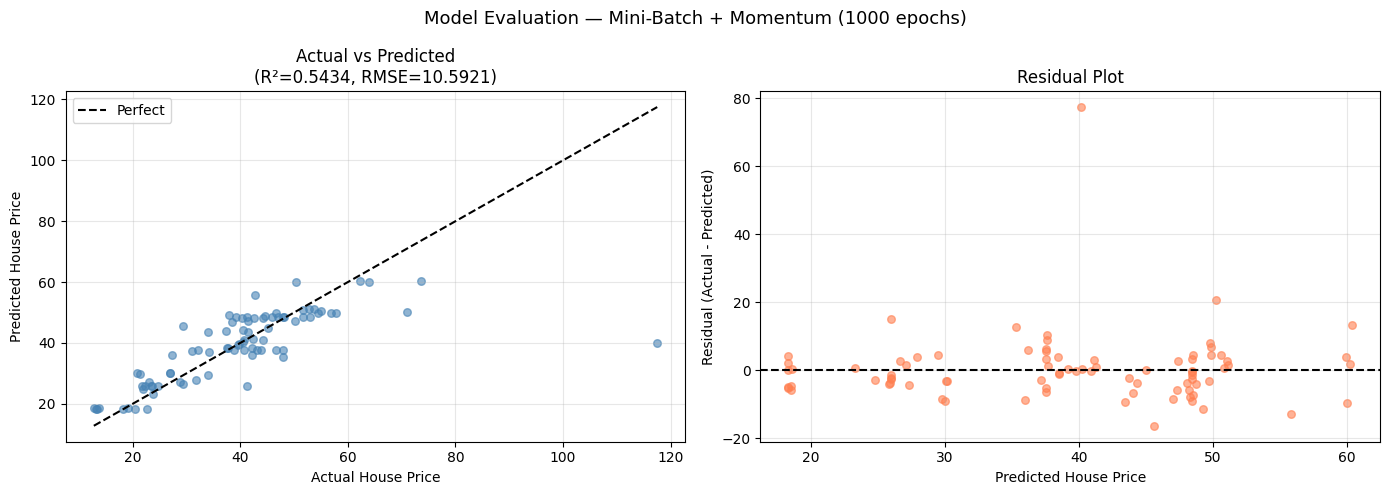

In [66]:
# --- Actual vs Predicted Table (first 15 samples) ---
print("\nActual vs Predicted — First 15 Test Samples")
print("-"*45)
print(f"{'#':<5} {'Actual':>10} {'Predicted':>12} {'Error':>10}")
print("-"*45)
for i in range(min(15, len(y_test))):
    actual = y_test[i][0]
    pred   = y_test_pred[i][0]
    err    = abs(actual - pred)
    print(f"{i+1:<5} {actual:>10.2f} {pred:>12.2f} {err:>10.2f}")

# --- Actual vs Predicted Scatter Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='steelblue', s=30)
min_val = float(min(y_test.min(), y_test_pred.min()))
max_val = float(max(y_test.max(), y_test_pred.max()))
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect')
axes[0].set_title(f'Actual vs Predicted\n(R²={r2:.4f}, RMSE={test_rmse:.4f})')
axes[0].set_xlabel('Actual House Price')
axes[0].set_ylabel('Predicted House Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test.flatten() - y_test_pred.flatten()
axes[1].scatter(y_test_pred.flatten(), residuals, alpha=0.6, color='coral', s=30)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted House Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — Mini-Batch + Momentum (1000 epochs)', fontsize=13)
plt.tight_layout()
plt.show()

Summary & Discussion

In [67]:

print("=" * 65)
print("SUMMARY")
print("=" * 65)

print("""
   Dataset:
   Real Estate Valuation Dataset
   414 samples, 6 input features, 1 target (house price/unit area)

 Neural Network Architecture:
   Input Layer  → 6 neurons
   Hidden Layer → 5 neurons (Sigmoid activation)
   Output Layer → 1 neuron  (Linear — regression)

 Training Details:
   Loss Function  : Mean Squared Error (MSE)
   Normalization  : Z-score standardization
   Train/Test     : 80% / 20% split

 Optimizers Implemented:
   Batch Gradient Descent
   Stochastic Gradient Descent (SGD)
   Mini-Batch Gradient Descent
   Momentum (Batch / SGD / Mini-Batch)
   Nesterov Accelerated Gradient (Batch / SGD / Mini-Batch)

 Experiments Conducted:
   Learning Rate Comparison (0.001, 0.01, 0.1)
   Hidden Layer Size Comparison (1, 3, 5, 10 neurons)
   Optimizer Performance Comparison (9 variants)

 Key Findings:
   - Higher learning rate (0.1) converges faster but may overshoot
   - More hidden neurons generally reduce loss (diminishing returns)
   - Mini-Batch + Momentum typically achieves best balance of
     speed and stability
   - SGD is noisier but can generalize well
   - Nesterov gives smoother convergence than standard Momentum
""")

print("=" * 65)
print(f" Best Test MSE  : {test_mse:.4f}")
print(f" Best Test RMSE : {test_rmse:.4f}")
print(f" Best Test R²   : {r2:.4f}")
print(f" Best Test MAE  : {mae:.4f}")
print("=" * 65)

SUMMARY

   Dataset:
   Real Estate Valuation Dataset
   414 samples, 6 input features, 1 target (house price/unit area)

 Neural Network Architecture:
   Input Layer  → 6 neurons
   Hidden Layer → 5 neurons (Sigmoid activation)
   Output Layer → 1 neuron  (Linear — regression)

 Training Details:
   Loss Function  : Mean Squared Error (MSE)
   Normalization  : Z-score standardization
   Train/Test     : 80% / 20% split

 Optimizers Implemented:
   Batch Gradient Descent
   Stochastic Gradient Descent (SGD)
   Mini-Batch Gradient Descent
   Momentum (Batch / SGD / Mini-Batch)
   Nesterov Accelerated Gradient (Batch / SGD / Mini-Batch)

 Experiments Conducted:
   Learning Rate Comparison (0.001, 0.01, 0.1)
   Hidden Layer Size Comparison (1, 3, 5, 10 neurons)
   Optimizer Performance Comparison (9 variants)

 Key Findings:
   - Higher learning rate (0.1) converges faster but may overshoot
   - More hidden neurons generally reduce loss (diminishing returns)
   - Mini-Batch + Momentum typ